In [7]:
!pip install matplotlib


'pip' is not recognized as an internal or external command,
operable program or batch file.


In [9]:
import sys
!{sys.executable} -m pip install matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.3 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.3 MB 2.3 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.3 MB 1.7 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.3 MB 1.8 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.3 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.3 MB 2.0 MB/s eta 0:00:03
   ------------- -------------------------- 2.9/8.3 MB 1.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.3 MB 1.9 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.3 MB 1.8 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.3 MB 1.8 MB/s eta 0:00:03
   --------------------- ------------------ 4.5/8.3 MB 1.9 MB/s eta 0:00:03
   ---------------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [10]:
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [15]:
install_if_missing("PIL")


In [16]:
from PIL import Image, ImageOps


In [ ]:
# ---------- AUTO FIX FOR MISSING LIBRARIES ----------
import sys
import subprocess

def install_if_missing(import_name, pip_name=None):
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        if pip_name is None:
            pip_name = import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

install_if_missing("matplotlib")
install_if_missing("PIL", "pillow")

# ---------- IMPORTS ----------
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np

# ---------- PATHS ----------
BASE_DIR = r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest"

CROP_FOLDERS = {
    "cotton_bollworm": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\cotton_bollworm",
    "Oriental_fruit_fly": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\Oriental_fruit_fly",
    "Peach_Aphid": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\Peach_Aphid",
    "Silverleaf_Whitefly": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\Silverleaf_Whitefly",
    "Thrips": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\Thrips",
    "two-spotted_spider_mite": r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest\two-spotted_spider_mite"
}

# ---------- IMAGE COLLECTION ----------
def collect_images(crop_folders):
    image_data = []
    print("Scanning folders...")

    for label, folder_path in crop_folders.items():
        if not os.path.exists(folder_path):
            print(f"Warning: Folder not found -> {folder_path}")
            continue

        # Collect all images directly in this folder
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        for img_file in images:
            img_full_path = os.path.join(folder_path, img_file)
            image_data.append({
                "label": label.replace("_", " ").title(),
                "path": img_full_path
            })

    return image_data

# ---------- MAIN ----------
data = collect_images(CROP_FOLDERS)
total_images = len(data)
print(f"Total images found: {total_images}")

if total_images == 0:
    raise RuntimeError(
        "No images found! Check folder paths and image extensions (.jpg, .jpeg, .png)."
    )

cols = 7
rows = max(1, math.ceil(total_images / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 3.5 * rows))
fig.suptitle(
    "Figure 1: Representative sample images from the Agri-Vision4 dataset",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# Flatten axes safely
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < total_images:
        item = data[i]
        try:
            img = Image.open(item["path"])
            img = ImageOps.fit(img, (300, 300), Image.LANCZOS)
            ax.imshow(img)
            ax.set_title(item["label"].replace(" ", "\n"), fontsize=10, fontweight="bold")
            ax.axis("off")
        except Exception as e:
            print(f"Image error: {e}")
            ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.4, wspace=0.1)

save_path = "Figure_1_Sample_Images_Fixed.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Images generated successfully")
print(f"Saved at: {save_path}")


Scanning folders...
Total images found: 1396


KeyboardInterrupt: 

Picking 1 random image per folder...
Total images selected: 6


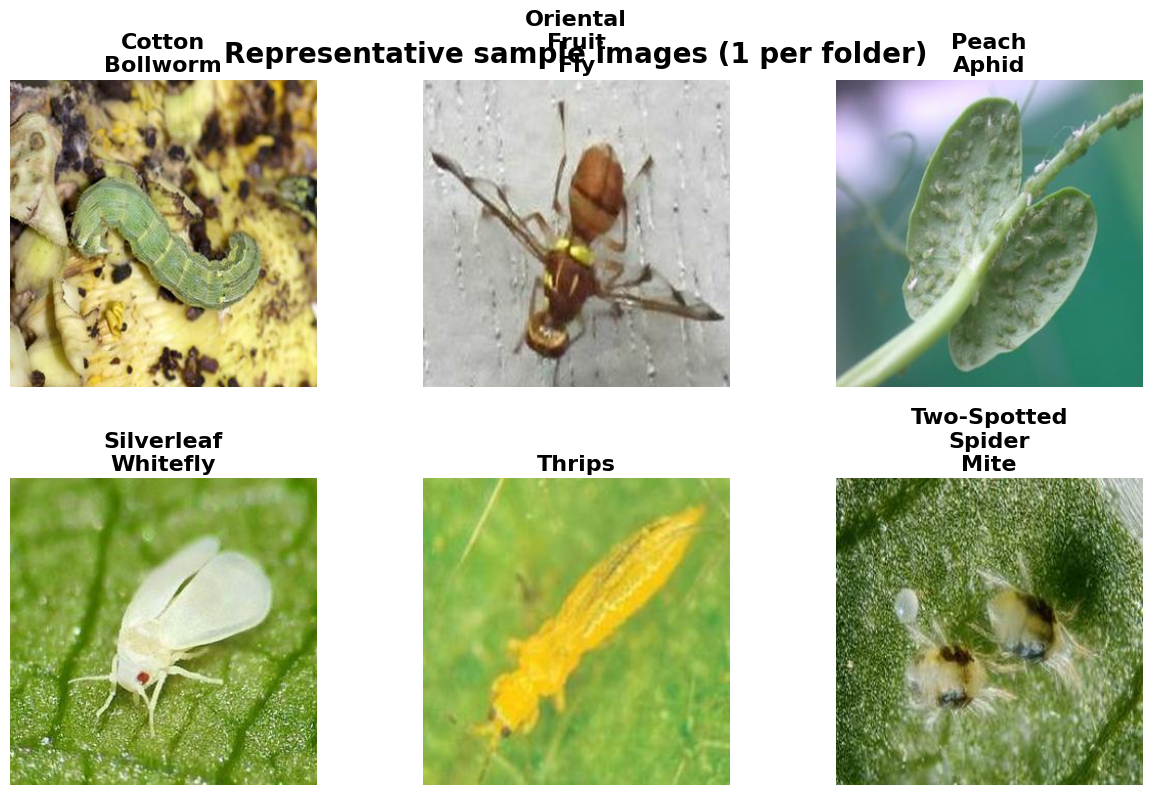

✅ Visualization complete!
Saved at: Figure_1_3x2_One_Image_Per_Folder_Font16.jpg


In [ ]:
# ---------- AUTO FIX FOR MISSING LIBRARIES ----------
import sys
import subprocess

def install_if_missing(import_name, pip_name=None):
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        if pip_name is None:
            pip_name = import_name
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])

install_if_missing("matplotlib")
install_if_missing("PIL", "pillow")
install_if_missing("numpy")

# ---------- IMPORTS ----------
import os
import random
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import numpy as np

# ---------- PATHS ----------
BASE_DIR = r"F:\ALL Journal Paper\tomato_Journal Paper\Before work\Original_image_of_tomato_pest"

CROP_FOLDERS = {
    "cotton_bollworm": os.path.join(BASE_DIR, "cotton_bollworm"),
    "Oriental_fruit_fly": os.path.join(BASE_DIR, "Oriental_fruit_fly"),
    "Peach_Aphid": os.path.join(BASE_DIR, "Peach_Aphid"),
    "Silverleaf_Whitefly": os.path.join(BASE_DIR, "Silverleaf_Whitefly"),
    "Thrips": os.path.join(BASE_DIR, "Thrips"),
    "two-spotted_spider_mite": os.path.join(BASE_DIR, "two-spotted_spider_mite")
}

# ---------- IMAGE COLLECTION ----------
def collect_one_image_per_folder(crop_folders):
    image_data = []
    print("Picking 1 random image per folder...")

    for label, folder_path in crop_folders.items():
        if not os.path.exists(folder_path):
            print(f"Warning: Folder not found -> {folder_path}")
            continue

        # Only images directly in the folder
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg")) and os.path.isfile(os.path.join(folder_path, f))
        ]

        if images:
            selected_img = random.choice(images)
            img_full_path = os.path.join(folder_path, selected_img)
            image_data.append({
                "label": label.replace("_", " ").title(),
                "path": img_full_path
            })

    return image_data

# ---------- MAIN ----------
data = collect_one_image_per_folder(CROP_FOLDERS)
total_images = len(data)
print(f"Total images selected: {total_images}")

if total_images == 0:
    raise RuntimeError("No images found! Check folder paths and image extensions (.jpg, .jpeg, .png).")

# Fixed grid: 3 columns × 2 rows
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
fig.suptitle(
    "",
    fontsize=20,
    fontweight="bold",
    y=0.95
)

# Flatten axes safely
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < total_images:
        item = data[i]
        try:
            img = Image.open(item["path"])
            img = ImageOps.fit(img, (300, 300), Image.LANCZOS)
            ax.imshow(img)
            ax.set_title(item["label"].replace(" ", "\n"), fontsize=16, fontweight="bold")  # <- FONT SIZE 16
            ax.axis("off")
        except Exception as e:
            print(f"Image error: {e}")
            ax.axis("off")
    else:
        ax.axis("off")  # empty spots

plt.tight_layout()
plt.subplots_adjust(top=0.90, hspace=0.3, wspace=0.2)

save_path = "Figure_1_3x2_One_Image_Per_Folder_Font16.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("✅ Visualization complete!")
print(f"Saved at: {save_path}")
